## Load packages

In [1]:
import pandas as pd
import anndata as ad
import numpy as np
import scanpy as sc

from pydeseq2.dds import DeseqDataSet

from utils import plot_mean_over_variance, plot_sample_distance_heatmap, plot_raw_vs_normed_counts, pca_from_adata, plot_pca_plotly

## Import Data

In [2]:
adata = sc.read_h5ad("./data/adata_filter_genes.h5ad")

## Plot mean over variance

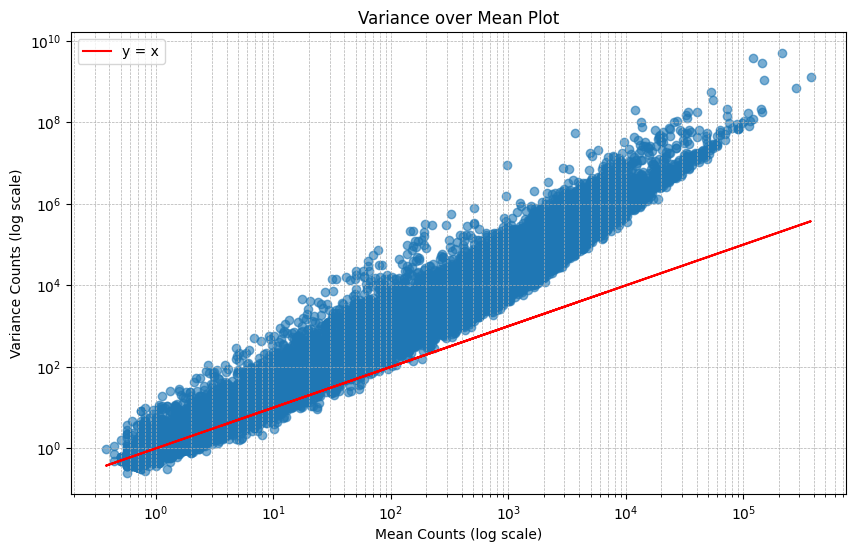

In [3]:
plot_mean_over_variance(adata,save='mean_over_variance')

## Create basic model

In [4]:
dds = DeseqDataSet(
    adata=adata,
    design='~condition',  # compare samples based on the "condition"
    # column ("B" vs "A")
    refit_cooks=True,
)

In [5]:
dds.deseq2()

Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 2.85 seconds.

Fitting dispersion trend curve...
... done in 0.50 seconds.

Fitting MAP dispersions...
... done in 3.80 seconds.

Fitting LFCs...
... done in 1.82 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 0 outlier genes.



In [6]:
dds.vst()

Fit type used for VST : parametric


Fitting dispersions...
... done in 3.03 seconds.



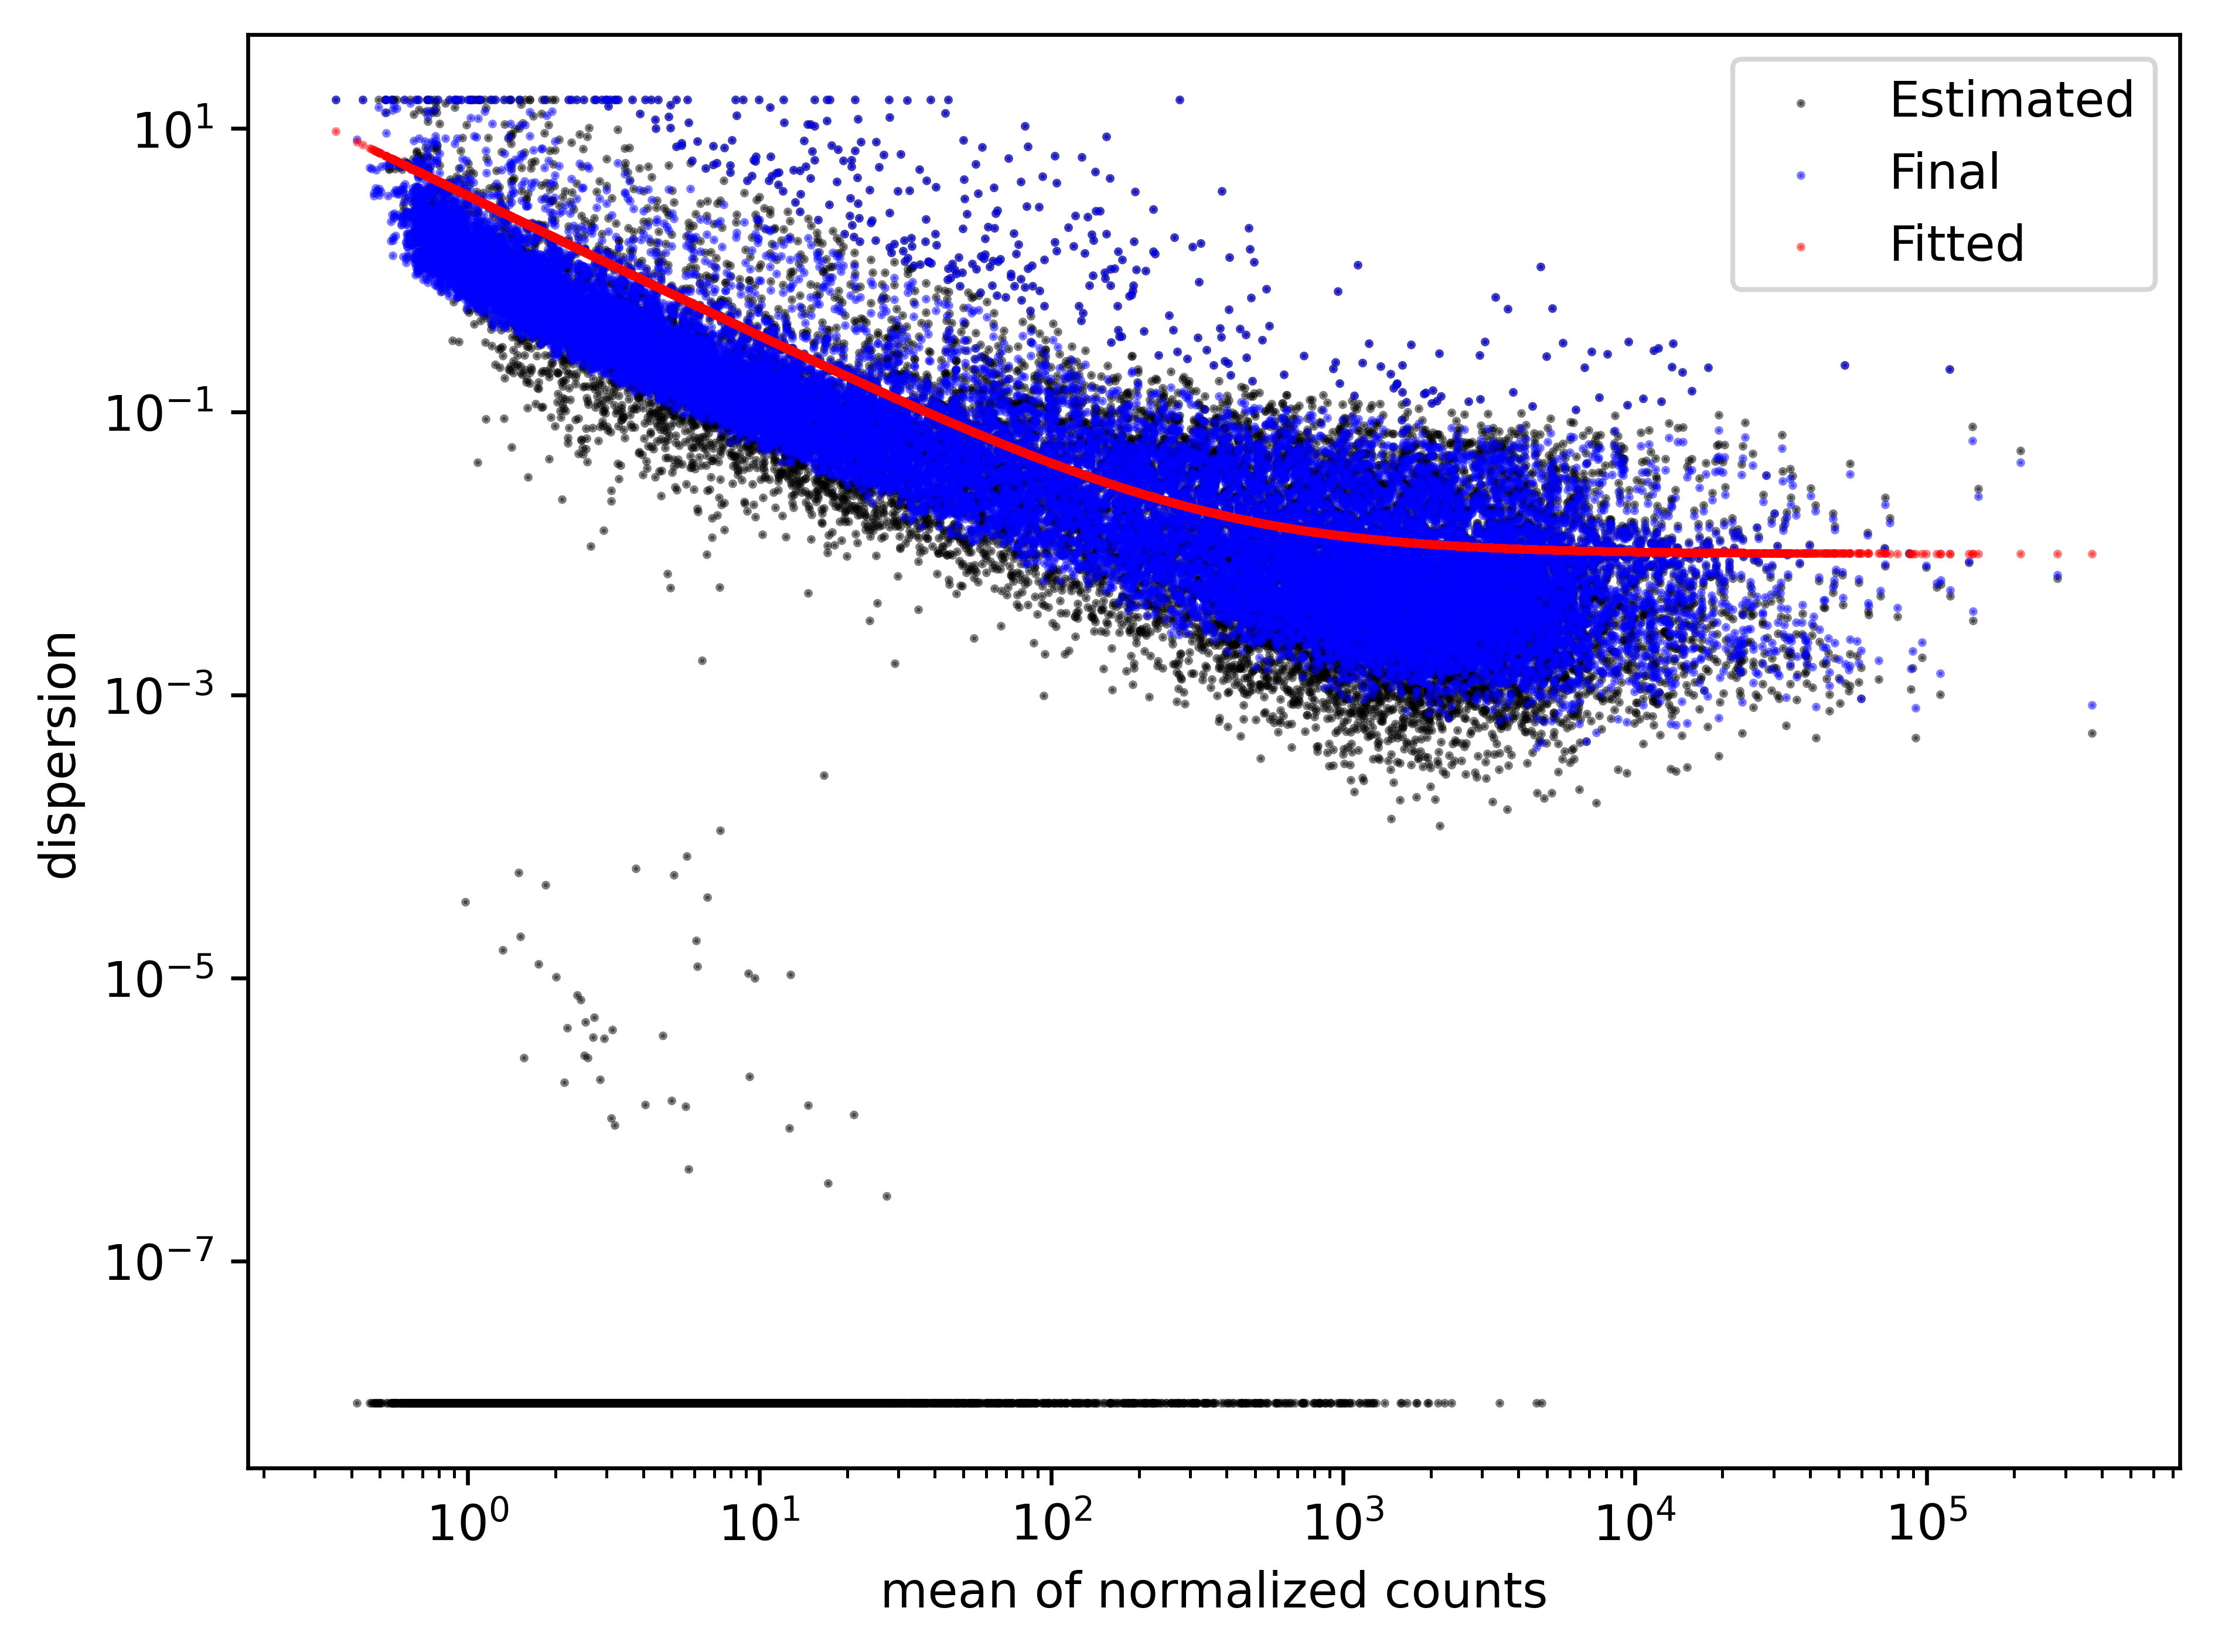

In [7]:
dds.plot_dispersions(save_path = "./results/QC/dispersion.png")

## Compute PCA and UMAP

In [8]:
sc.tl.pca(adata,layer='vst_counts')

In [9]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

In [10]:
adata.layers['raw_counts'] = adata.X.copy()
adata.X = adata.layers['normed_counts']

## heatmap

In [11]:
adata

AnnData object with n_obs × n_vars = 16 × 22289
    obs: 'treatment', 'stimulation', 'Age', 'condition'
    var: 'gene_name'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var', 'vst_trend_coeffs', 'pca', 'neighbors', 'umap'
    obsm: 'design_matrix', 'size_factors', '_mu_LFC', '_hat_diagonals', 'replaceable', 'X_pca', 'X_umap'
    varm: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier', 'vst_genewise_dispersions', 'PCs'
    layers: 'normed_counts', '_mu_hat', 'cooks', '_vst_mu_hat', 'vst_counts', 'raw_counts'
    obsp: 'distances', 'connectivities'

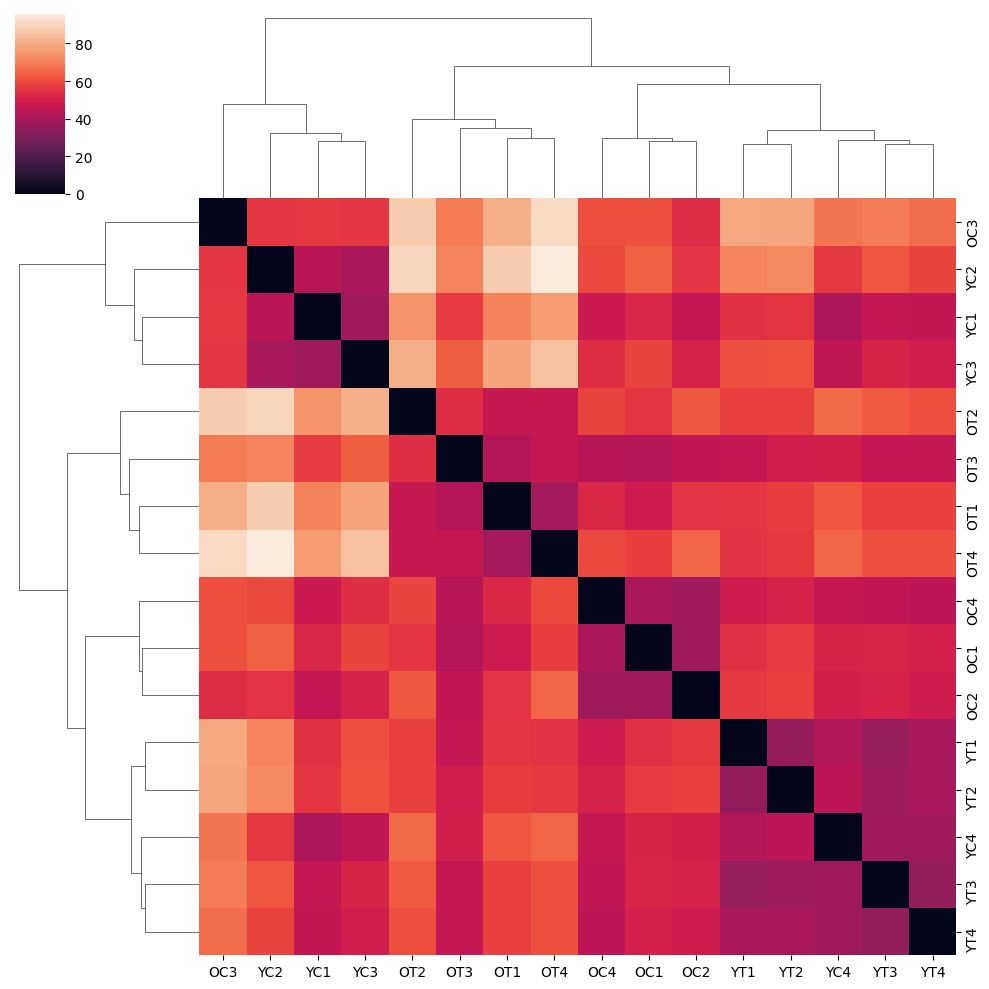

In [12]:
plot_sample_distance_heatmap(adata,layer='vst_counts')

## Boxplot

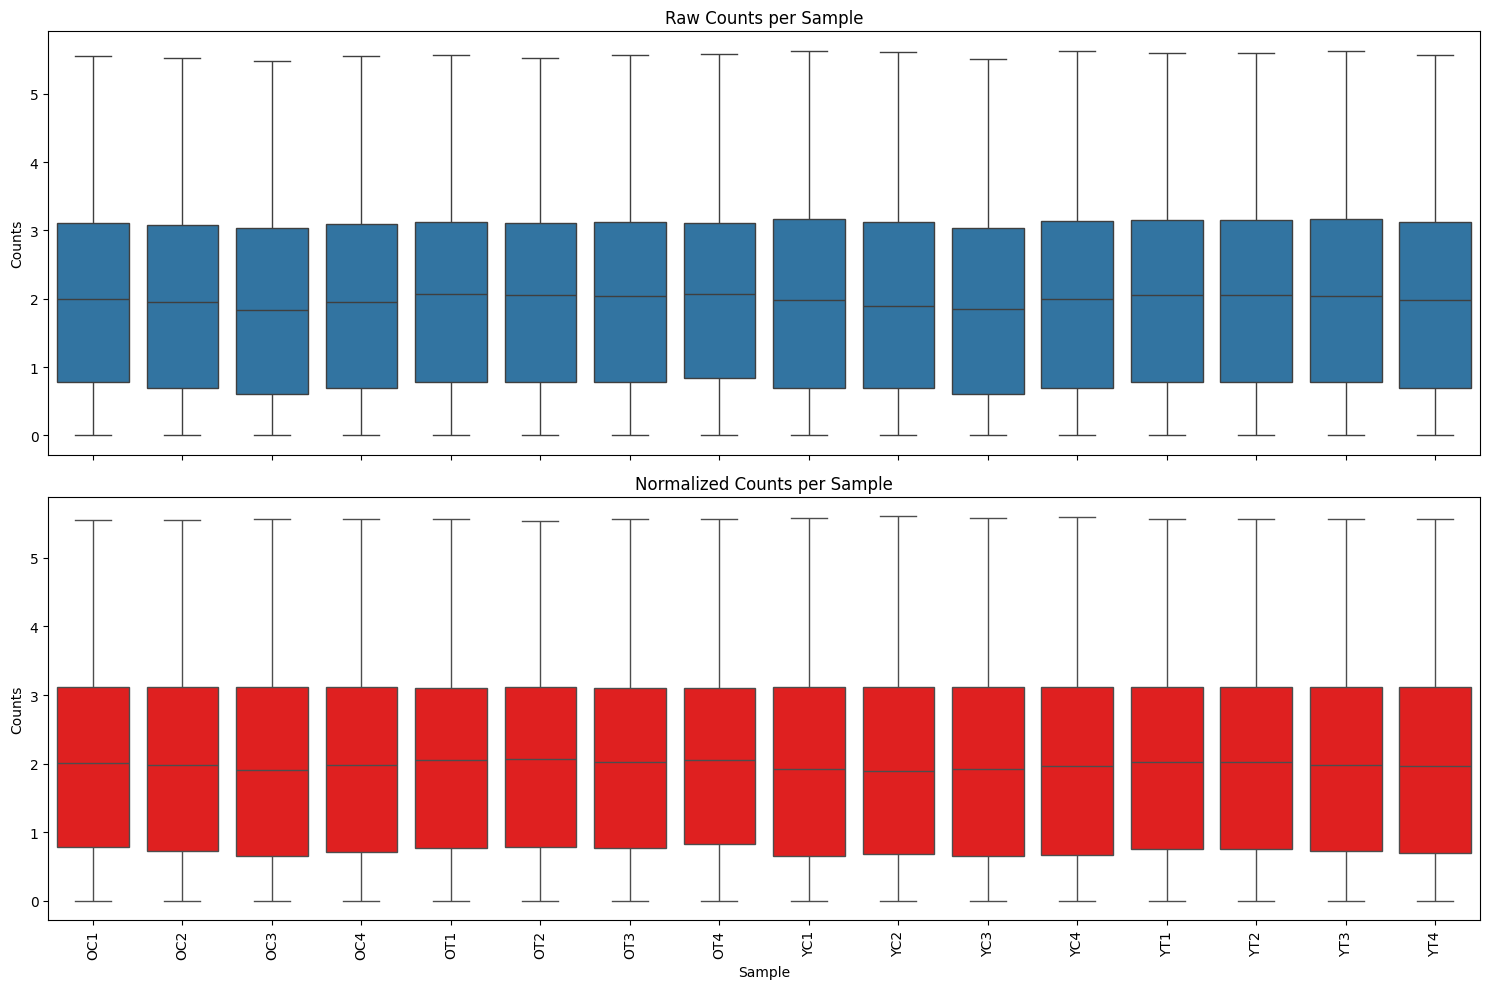

In [13]:
plot_raw_vs_normed_counts(adata=adata,save='raw_vs_normed_counts')

## PCA

In [14]:
pca_data,var = pca_from_adata(adata)
plot_pca_plotly(pca_data,var,save='PCA_allGenes',title='ALL Genes')

['Control_Old', 'Trained_Old', 'Control_Young', 'Trained_Young']
['Trained_Old', 'Control_Old', 'Control_Young', 'Trained_Young']


In [15]:
sc.pp.highly_variable_genes(adata,n_top_genes=1000,layer='vst_counts')
sc.pp.pca(adata,layer='vst_counts')

In [16]:
pca_data,var = pca_from_adata(adata)
plot_pca_plotly(pca_data,var,save='PCA_top1000Genes', title='Top 1000 HVGs')

['Control_Old', 'Trained_Old', 'Control_Young', 'Trained_Young']
['Trained_Old', 'Control_Old', 'Control_Young', 'Trained_Young']
